# Clustering de Clientes con K-means incluyendo el Sexo

Este notebook repite el procedimiento de `clusters.ipynb`, pero ahora con **cuatro** variables: `age`, `annual_income_k`, `spending_score` **y `gender`**.

**Objetivo:** ver qué pasa con los clusters cuando metemos una variable **categórica binaria** en un algoritmo pensado para variables **numéricas continuas**, y comparar con el modelo sin sexo.

**Ruta del notebook:**
1. Carga de datos.
2. Codificación de `gender` como variable numérica.
3. Estandarización (y su efecto especial sobre una variable binaria).
4. Entrenamiento y gráficas para **k = 3, 4, 5, 6 y 10**.
5. **Método del codo (elbow)** y coeficiente de silueta.
6. Comparación contra el modelo sin sexo.
7. Conclusiones.

> La teoría completa de K-means (función objetivo, algoritmo de Lloyd, k-means++, supuestos) está en `clusters.ipynb`. Aquí solo repasamos lo necesario.

## Repaso rápido

K-means busca los centroides que minimizan la **inercia** (WCSS):

$$J = \sum_{c=1}^{k} \sum_{\mathbf{x}_i \in C_c} \lVert \mathbf{x}_i - \boldsymbol{\mu}_c \rVert^2 = \sum_{c=1}^{k} \sum_{\mathbf{x}_i \in C_c} \sum_{j=1}^{p} (x_{ij} - \mu_{cj})^2$$

La segunda forma es la importante hoy: **la inercia es una suma por variable**. Cada feature $j$ aporta su propio pedazo de inercia, y K-means va a preferir los cortes que eliminen más inercia. Ahora $p = 4$.

## 1. Librerías y carga de datos

In [1]:
import warnings
warnings.filterwarnings('ignore')  # Ocultamos avisos no críticos para que la salida sea legible

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # Para construir leyendas personalizadas (color = cluster, forma = sexo)
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style='whitegrid')

# Misma semilla que en clusters.ipynb para que la comparación entre notebooks sea justa
SEMILLA = 42

In [2]:
# Buscamos el CSV en la carpeta data (según desde dónde el IDE lance el kernel)
ruta_csv = Path('data/retailmax.csv')
if not ruta_csv.exists():
    ruta_csv = Path('../data/retailmax.csv')

df = pd.read_csv(ruta_csv)

# Mismos nombres de columnas que en el EDA y en clusters.ipynb
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income_k',
    'Spending Score (1-100)': 'spending_score'
})
df['gender'] = df['gender'].astype('category')

print('Dimensiones:', df.shape)
df.head()

Dimensiones: (200, 5)


,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Codificación de `gender`

K-means solo sabe restar números, así que `'Female'` / `'Male'` debe convertirse a número. Creamos **una sola** columna binaria:

$$\text{is\_female} = \begin{cases} 1 & \text{si es mujer} \\ 0 & \text{si es hombre} \end{cases}$$

**¿Por qué una columna y no dos (One-Hot completo con `is_female` e `is_male`)?**
Con dos columnas, una es exactamente $1 - $ la otra (información redundante, colinealidad perfecta). En distancia euclidiana eso **cuenta la diferencia de sexo dos veces**: entre un hombre y una mujer habría una diferencia en `is_female` **y** otra en `is_male`, así que el sexo pesaría el doble. Con dos categorías, una sola columna contiene toda la información.

**¿Por qué no usar 1 = hombre, 2 = mujer?** Para dos categorías daría lo mismo después de estandarizar, pero con 3 o más categorías inventaría un **orden** y distancias que no existen (1, 2, 3). La codificación 0/1 es la forma estándar.

In [3]:
# 1 = mujer, 0 = hombre
df['is_female'] = (df['gender'] == 'Female').astype(int)

# Features del modelo: las tres numéricas + el sexo codificado
FEATURES = ['age', 'annual_income_k', 'spending_score', 'is_female']

ETIQUETAS = {
    'age': 'Edad (años)',
    'annual_income_k': 'Ingreso anual (k$)',
    'spending_score': 'Spending score (1-100)',
    'is_female': 'Es mujer (1 = sí)'
}

X = df[FEATURES].copy()
X.describe().T[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
age,38.85,13.97,18.0,70.0
annual_income_k,60.56,26.26,15.0,137.0
spending_score,50.20,25.82,1.0,99.0
is_female,0.56,0.50,0.0,1.0


Observa `is_female`: su media es $p = 0.56$, es decir, **la proporción de mujeres**. Para una variable 0/1 (Bernoulli) la media es $p$ y la desviación estándar es $\sqrt{p(1-p)}$.

## 3. Estandarización y el problema de la variable binaria

Aplicamos el mismo z-score a las cuatro variables: $z = \frac{x - \bar{x}}{\sigma}$.

Para `is_female`, con $p = 0.56$ y $\sigma = \sqrt{0.56 \cdot 0.44} \approx 0.496$, solo existen **dos valores posibles**:

$$z_{\text{mujer}} = \frac{1 - 0.56}{0.496} \approx 0.886 \qquad z_{\text{hombre}} = \frac{0 - 0.56}{0.496} \approx -1.128$$

La distancia entre un hombre y una mujer en esa dimensión es $\approx 2.01$ desviaciones estándar, **y no hay nadie en medio**.

### ¿Por qué esto es un problema para K-means? (argumento con la inercia)
Tras estandarizar, cada variable aporta $n \cdot \sigma^2 = 200 \cdot 1 = 200$ unidades de inercia con $k=1$ (total $= 4 \times 200 = 800$).

- **Cortar por sexo** (mujeres en un grupo, hombres en otro) deja la varianza de `is_female` **en 0 dentro de cada grupo**: elimina **las 200 unidades completas** de esa variable con un solo corte.
- **Cortar una variable continua** en dos (por ejemplo, en su mediana) elimina como mucho una fracción. Para una variable normal, el corte en la mediana elimina $\frac{2}{\pi} \approx 64\%$ de su varianza, unas 127 unidades.

Conclusión: **para K-means, separar por sexo es el corte más "barato"** para bajar la inercia, aunque hombres y mujeres se comporten igual en ingreso y gasto (como vimos en el EDA). Por eso esperamos clusters "puros" de un solo sexo.

**Ventajas de incluir el sexo:**
- Si el negocio **quiere** campañas diferenciadas por sexo, los clusters ya salen separados.
- Si existiera una diferencia real de comportamiento por sexo, el modelo podría capturarla.

**Desventajas:**
- La variable binaria puede **dominar** la segmentación y "partir en dos" grupos que en realidad son el mismo comportamiento de compra.
- El centroide de `is_female` (por ejemplo 0.54) no representa a ninguna persona real.
- K-means supone variables continuas; con una binaria se rompen los supuestos de clusters esféricos.

**Alternativas:**
- **K-prototypes** (librería `kmodes`): usa distancia euclidiana para las numéricas y *matching* (0 si coinciden, 1 si no) para las categóricas, con un peso $\gamma$ que controla cuánto importa la parte categórica.
- **Distancia de Gower** + clustering jerárquico o K-medoids: diseñada para datos mixtos.
- **Bajar el peso** de `is_female` (multiplicarla por un factor $w < 1$ después de estandarizar).
- **No incluirla** y usarla solo para describir los clusters (lo que hicimos en `clusters.ipynb`).

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Comprobación: medias ≈ 0 y desviaciones ≈ 1 en las cuatro variables
display(pd.DataFrame(X_scaled, columns=FEATURES).describe().T[['mean', 'std', 'min', 'max']].round(3))

# is_female estandarizada solo toma dos valores: uno para mujeres y otro para hombres
valores_sexo = np.unique(X_scaled[:, FEATURES.index('is_female')])
print('Valores posibles de is_female estandarizada:', valores_sexo.round(3))
print('Distancia entre hombre y mujer en esa dimensión:', round(valores_sexo[1] - valores_sexo[0], 3))

,mean,std,min,max
age,-0.0,1.003,-1.496,2.236
annual_income_k,-0.0,1.003,-1.739,2.918
spending_score,-0.0,1.003,-1.910,1.894
is_female,-0.0,1.003,-1.128,0.886


Valores posibles de is_female estandarizada: [-1.128  0.886]
Distancia entre hombre y mujer en esa dimensión: 2.015


## 4. Clustering con k = 3, 4, 5, 6 y 10

Mismo proceso que en `clusters.ipynb`. Como no podemos dibujar 4 dimensiones, representamos el sexo con la **forma** del marcador:
- **Círculo (●) = mujer**, **Triángulo (▲) = hombre**.
- El **color** indica el cluster y la **X negra** es el centroide.

En la tabla de perfil, la columna `pct_mujeres` es clave: si vale **0% o 100%**, ese cluster está formado por un solo sexo.

In [5]:
def entrenar_kmeans(k, X_esc):
    # Crea y entrena un modelo K-means con k clusters; devuelve el modelo y la etiqueta de cada cliente
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA)
    etiquetas = modelo.fit_predict(X_esc)
    return modelo, etiquetas


# Forma del marcador según el sexo
MARCADORES = {1: 'o', 0: '^'}  # 1 = mujer (círculo), 0 = hombre (triángulo)


def graficar_clusters(k, etiquetas, centroides):
    colores = sns.color_palette('tab10', n_colors=k)
    fig = plt.figure(figsize=(20, 6))

    # --- Vista 3D (edad, ingreso, gasto); el sexo va en la forma del marcador ---
    ax3d = fig.add_subplot(1, 3, 1, projection='3d')
    for c in range(k):
        for sexo, marcador in MARCADORES.items():
            mascara = (etiquetas == c) & (X['is_female'] == sexo)
            ax3d.scatter(X.loc[mascara, 'age'], X.loc[mascara, 'annual_income_k'], X.loc[mascara, 'spending_score'],
                         color=colores[c], marker=marcador, s=35, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax3d.scatter(centroides['age'], centroides['annual_income_k'], centroides['spending_score'],
                 color='black', marker='X', s=220, depthshade=False)
    ax3d.set_xlabel(ETIQUETAS['age'])
    ax3d.set_ylabel(ETIQUETAS['annual_income_k'])
    ax3d.set_zlabel(ETIQUETAS['spending_score'])
    ax3d.set_title('Vista 3D (edad, ingreso, gasto)', fontsize=12, fontweight='bold')
    ax3d.view_init(elev=20, azim=-60)

    # --- Proyecciones 2D ---
    pares = [('annual_income_k', 'spending_score'), ('age', 'spending_score')]
    for i, (fx, fy) in enumerate(pares, start=2):
        ax = fig.add_subplot(1, 3, i)
        for c in range(k):
            for sexo, marcador in MARCADORES.items():
                mascara = (etiquetas == c) & (X['is_female'] == sexo)
                ax.scatter(X.loc[mascara, fx], X.loc[mascara, fy], color=colores[c], marker=marcador, s=45,
                           alpha=0.8, edgecolor='white', linewidth=0.4)
        ax.scatter(centroides[fx], centroides[fy], color='black', marker='X', s=220)
        ax.set_xlabel(ETIQUETAS[fx])
        ax.set_ylabel(ETIQUETAS[fy])
        ax.set_title(f'{ETIQUETAS[fx]} vs. {ETIQUETAS[fy]}', fontsize=12, fontweight='bold')

    # Leyenda manual: un cuadro de color por cluster + formas para el sexo + centroide
    handles = [Line2D([0], [0], marker='s', color='w', markerfacecolor=colores[c], markersize=11, label=f'Cluster {c}')
               for c in range(k)]
    handles += [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=9, label='Mujer'),
                Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=9, label='Hombre'),
                Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=13, label='Centroide')]
    fig.legend(handles=handles, loc='center right', fontsize=10, frameon=True)
    fig.suptitle(f'K-means con k = {k} (incluyendo sexo)', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    plt.show()


def perfil_clusters(etiquetas):
    # Resumen por cluster en unidades reales
    perfil = (X.assign(cluster=etiquetas)
                .groupby('cluster')
                .agg(n_clientes=('age', 'size'),
                     edad_media=('age', 'mean'),
                     ingreso_medio_k=('annual_income_k', 'mean'),
                     gasto_medio=('spending_score', 'mean'),
                     pct_mujeres=('is_female', 'mean')))
    perfil['pct_mujeres'] = perfil['pct_mujeres'] * 100
    return perfil.round(1)


resultados = {}
etiquetas_por_k = {}  # Guardamos las etiquetas para compararlas después con el modelo sin sexo


def ejecutar_k(k):
    # Entrena, grafica y resume un modelo con k clusters
    modelo, etiquetas = entrenar_kmeans(k, X_scaled)
    centroides = pd.DataFrame(scaler.inverse_transform(modelo.cluster_centers_), columns=FEATURES)
    silueta = silhouette_score(X_scaled, etiquetas)
    perfil = perfil_clusters(etiquetas)
    # ¿Cuántos clusters son de un solo sexo? (menos de 5% o más de 95% de mujeres)
    puros = int(((perfil['pct_mujeres'] <= 5) | (perfil['pct_mujeres'] >= 95)).sum())
    resultados[k] = {'inercia': modelo.inertia_, 'silueta': silueta, 'clusters_de_un_solo_sexo': puros}
    etiquetas_por_k[k] = etiquetas

    graficar_clusters(k, etiquetas, centroides)
    print(f'Inercia (WCSS): {modelo.inertia_:.2f}   |   Silueta: {silueta:.3f}   |   '
          f'Clusters de un solo sexo: {puros} de {k}')
    return perfil

### k = 3

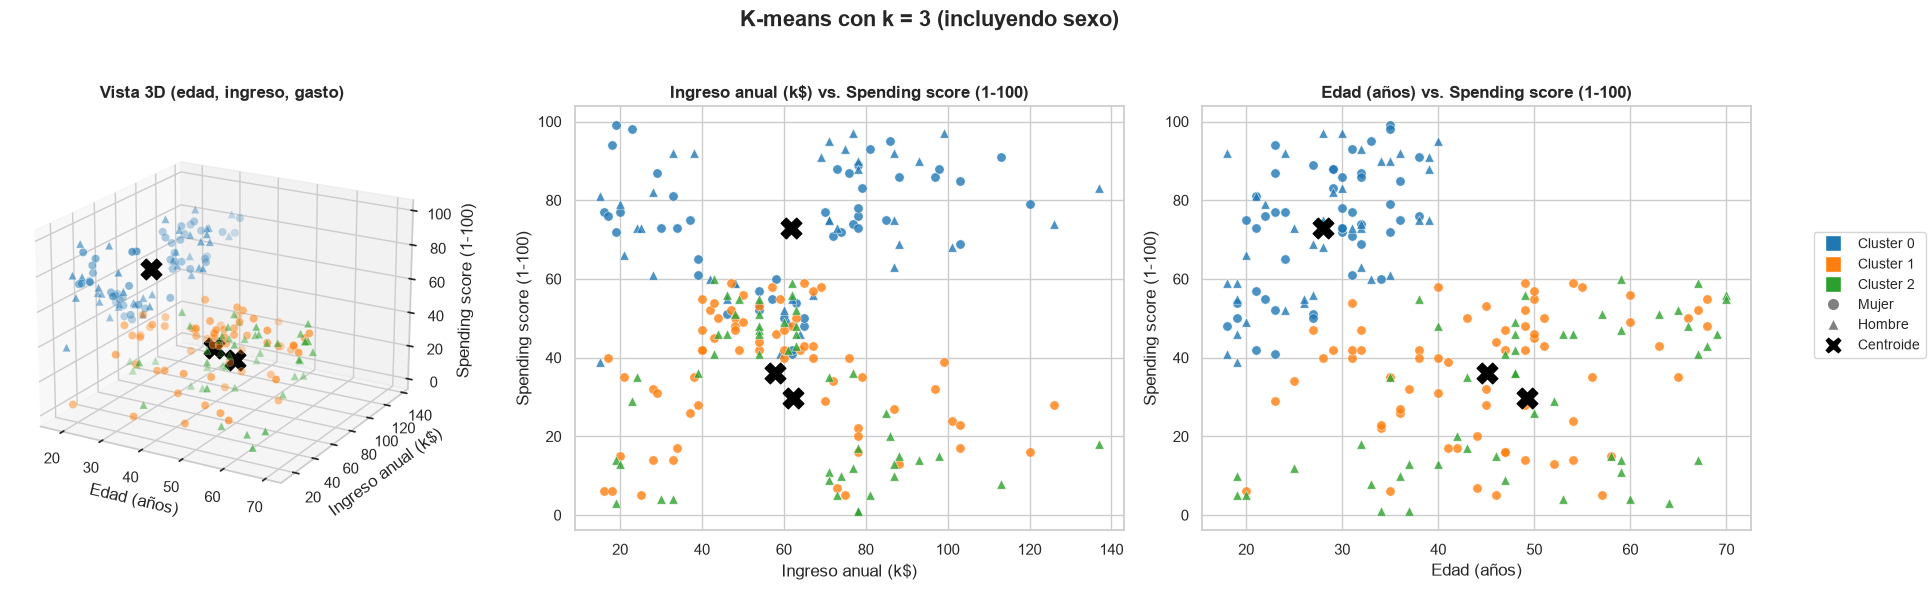

Inercia (WCSS): 476.79   |   Silueta: 0.260   |   Clusters de un solo sexo: 2 de 3


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,85,28.0,61.8,72.9,54.1
1,66,45.1,57.7,36.2,100.0
2,49,49.2,62.2,29.7,0.0


In [6]:
ejecutar_k(3)

**Lectura:** el efecto del sexo aparece desde el inicio. Hay un grupo **joven (~28 años) de gasto alto** (~73) mixto, y el resto de los clientes (mayores, gasto bajo) **se parte por sexo**: un cluster de solo mujeres (~45 años) y otro de solo hombres (~49 años), con perfiles de ingreso y gasto casi idénticos.

Compara con `clusters.ipynb`: sin sexo, k = 3 separaba a los clientes premium (ingreso y gasto altos). Aquí ese grupo desaparece porque K-means "gastó" un cluster en separar sexos.

### k = 4

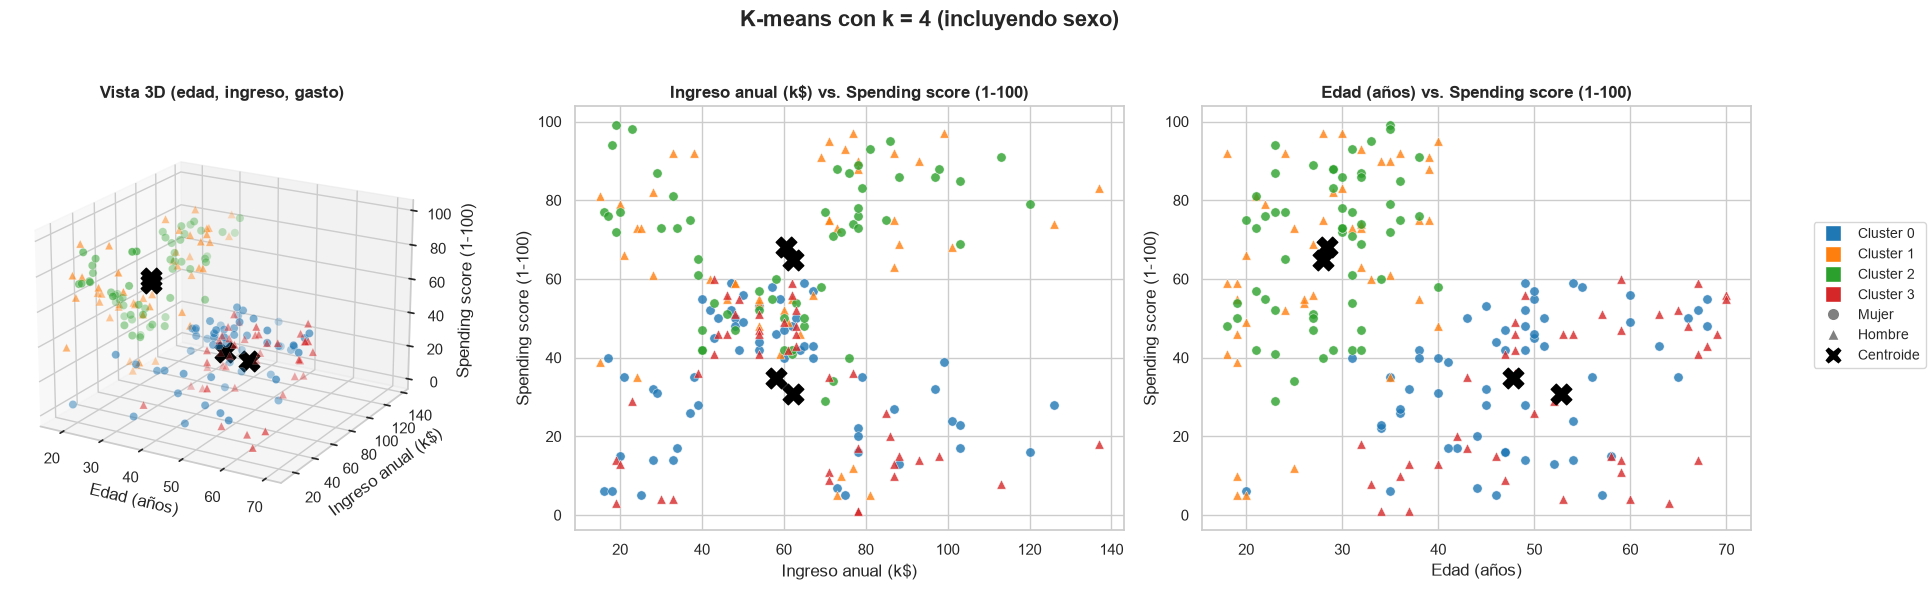

Inercia (WCSS): 388.72   |   Silueta: 0.298   |   Clusters de un solo sexo: 4 de 4


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,56,47.8,58.1,34.9,100.0
1,46,28.0,62.2,64.8,0.0
2,56,28.4,60.4,68.2,100.0
3,42,52.7,62.2,30.6,0.0


In [7]:
ejecutar_k(4)

**Lectura:** los **4 clusters son de un solo sexo**. El modelo solo hizo dos cortes: **sexo** × **edad/gasto** (jóvenes que gastan más vs. mayores que gastan menos). El ingreso anual casi no participa: los cuatro grupos tienen ingreso medio de ~58–62 k\$.

Es el caso más claro del problema: los grupos "jóvenes mujeres" y "jóvenes hombres" tienen prácticamente el mismo comportamiento de compra, pero el modelo los trata como segmentos distintos.

### k = 5

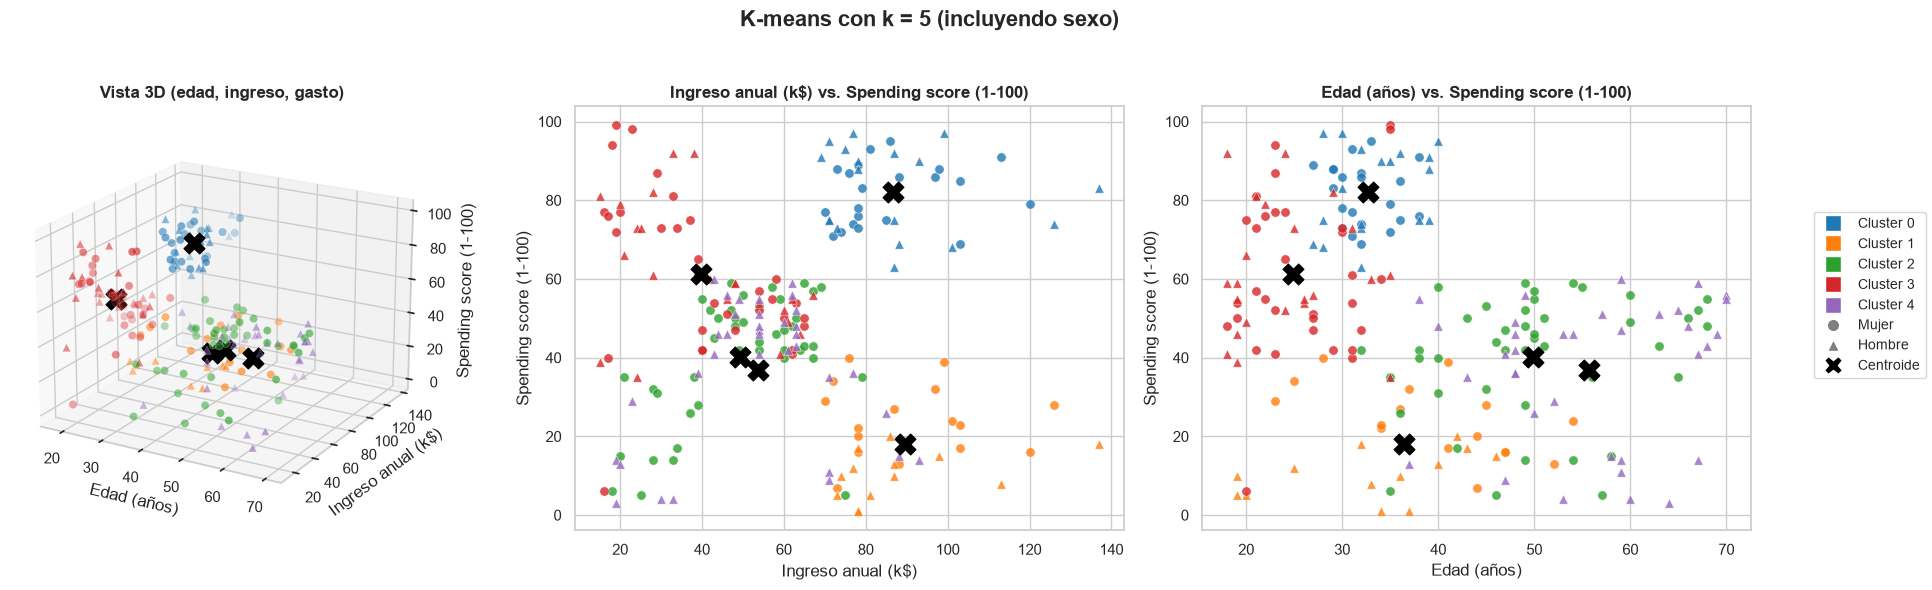

Inercia (WCSS): 331.31   |   Silueta: 0.304   |   Clusters de un solo sexo: 2 de 5


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,39,32.7,86.5,82.1,53.8
1,29,36.5,89.5,18.0,55.2
2,43,49.8,49.2,40.1,100.0
3,54,24.9,39.7,61.2,59.3
4,35,55.7,53.7,36.8,0.0


In [8]:
ejecutar_k(5)

**Lectura:** reaparecen los segmentos por ingreso: **premium** (ingreso ~87 k\$, gasto ~82) y **ahorradores** (ingreso ~90 k\$, gasto ~18), ambos **mixtos** (~55% mujeres, igual que el total). También hay un grupo joven de ingreso bajo y gasto alto, mixto. Solo los clientes **mayores de gasto medio-bajo** se dividen por sexo (uno 100% mujeres y otro 100% hombres).

Es la segmentación más parecida a la del modelo sin sexo: cuando los grupos por ingreso/gasto están muy separados, pesan más que el corte por sexo.

### k = 6

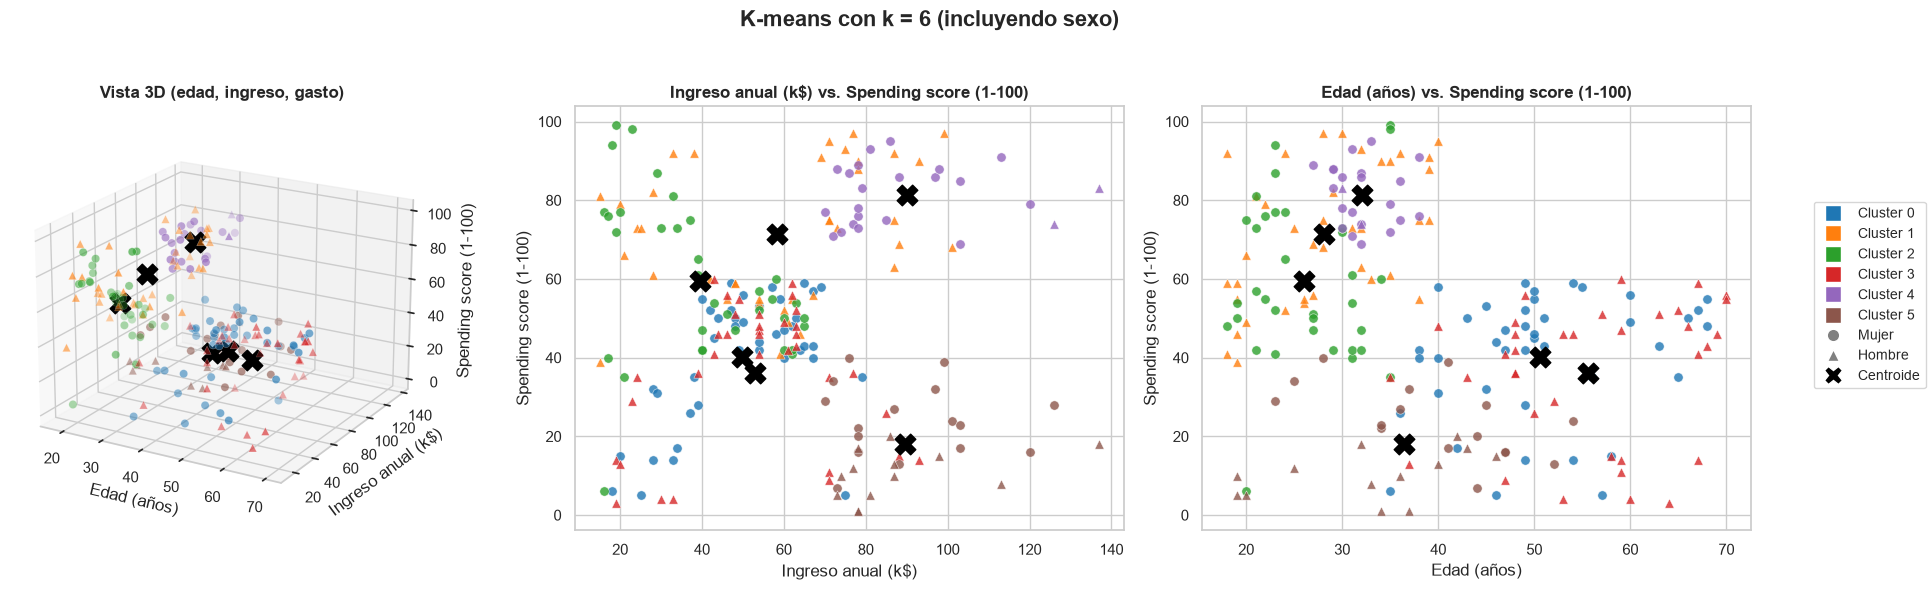

Inercia (WCSS): 276.41   |   Silueta: 0.331   |   Clusters de un solo sexo: 4 de 6


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,41,50.6,49.7,40.1,100.0
1,38,28.1,58.3,71.3,0.0
2,34,26.0,39.5,59.5,100.0
3,35,55.6,52.8,36.2,0.0
4,23,32.1,90.0,81.4,91.3
5,29,36.5,89.5,18.0,55.2


In [9]:
ejecutar_k(6)

**Lectura:** el grupo de jóvenes que antes era mixto ahora también se divide por sexo. Quedan **4 de 6 clusters de un solo sexo**; solo los premium (91% mujeres) y los ahorradores (55%) son mixtos. De nuevo, el modelo prefiere separar hombres y mujeres antes que encontrar nuevos comportamientos de compra.

### k = 10

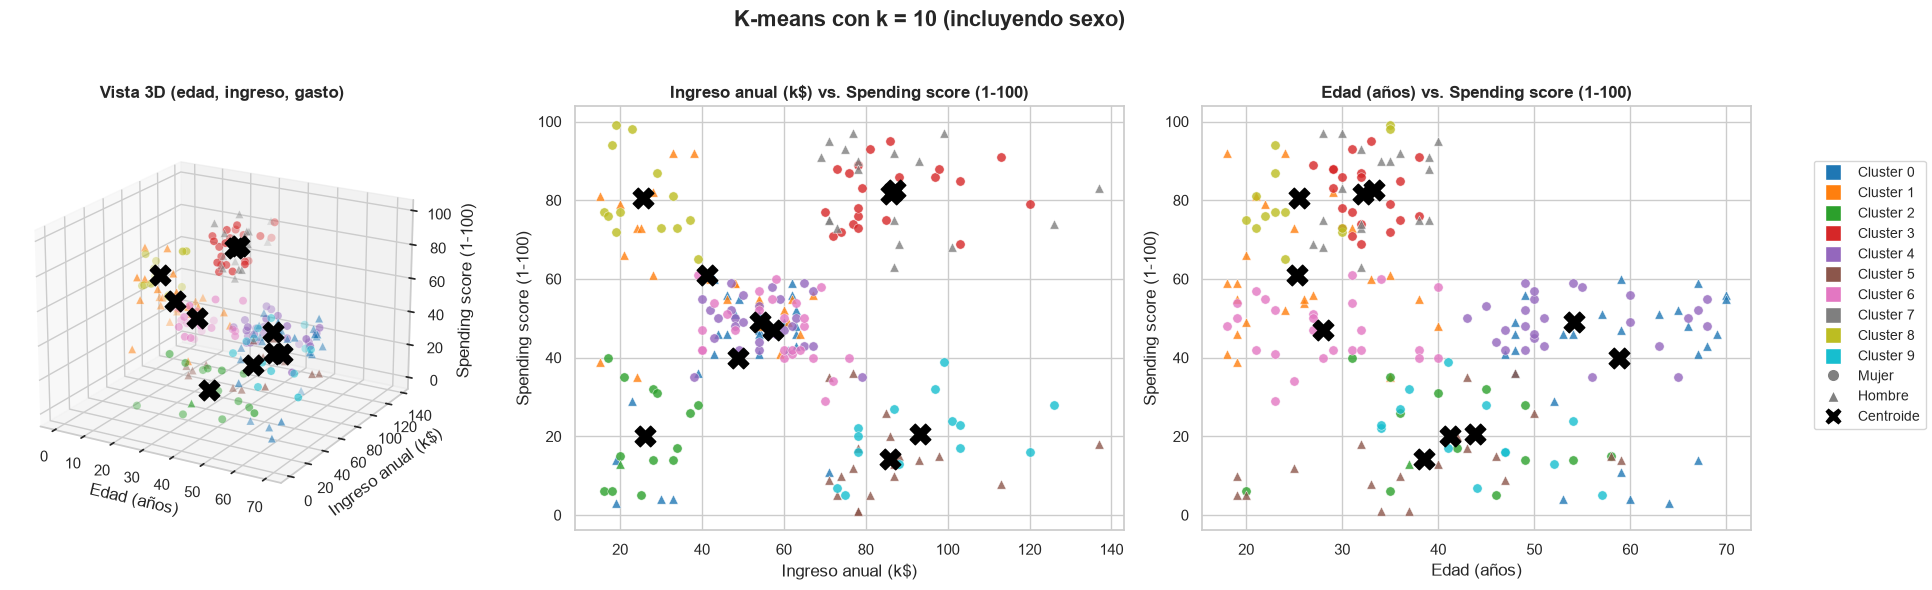

Inercia (WCSS): 152.03   |   Silueta: 0.421   |   Clusters de un solo sexo: 9 de 10


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,26,58.8,48.7,39.8,0.0
1,24,25.2,41.2,60.9,0.0
2,14,41.2,26.1,20.1,92.9
3,21,32.2,86.0,81.7,100.0
4,26,54.2,54.2,49.0,100.0
5,19,38.5,85.9,14.2,0.0
6,25,28.0,57.4,47.1,100.0
7,18,33.3,87.1,82.7,0.0
8,13,25.5,25.7,80.5,100.0


In [10]:
ejecutar_k(10)

**Lectura:** este resultado es muy revelador. Casi todos los clusters son de un solo sexo, y si los emparejamos vemos que son **aproximadamente los 5 segmentos de comportamiento del modelo sin sexo, duplicados** (una versión de mujeres y otra de hombres). Por ejemplo, hay premium mujeres (~86 k\$, gasto ~82) y premium hombres (~87 k\$, gasto ~83) con perfiles casi iguales.

Es decir: **k = 10 con sexo ≈ 5 comportamientos × 2 sexos**. El sexo no crea segmentos nuevos; solo multiplica los que ya existían.

In [11]:
# Comparación de los cinco modelos (con sexo)
comparacion = pd.DataFrame(resultados).T
comparacion.index.name = 'k'
comparacion['clusters_de_un_solo_sexo'] = comparacion['clusters_de_un_solo_sexo'].astype(int)
comparacion.round(3)

,inercia,silueta,clusters_de_un_solo_sexo
k,,,
3,476.788,0.260,2
4,388.718,0.298,4
5,331.310,0.304,2
6,276.412,0.331,4
10,152.030,0.421,9


## 5. Método del codo (Elbow Method)

Mismo procedimiento que en `clusters.ipynb`: entrenamos para $k = 1, \dots, 15$, graficamos la inercia y buscamos el $k$ con la **máxima distancia** a la recta que une el primer y el último punto (tras normalizar ambos ejes a $[0,1]$):

$$d = \frac{|x_n + y_n - 1|}{\sqrt{2}}$$

**Ojo:** las inercias de este notebook **no se pueden comparar directamente** con las de `clusters.ipynb`: aquí hay 4 variables estandarizadas, así que la inercia con $k = 1$ es $4 \times 200 = 800$ (antes era $3 \times 200 = 600$). Lo que sí se puede comparar es la **forma** de la curva y la silueta, que está acotada en $[-1, 1]$.

In [12]:
# Entrenamos K-means para k = 1..15 y guardamos la inercia de cada modelo
rango_k = list(range(1, 16))
inercias = []
for k in rango_k:
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA)
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)


def detectar_codo(ks, valores):
    # Normalizamos ambos ejes a [0, 1] para que la distancia no dependa de las unidades
    x = np.array(ks, dtype=float)
    y = np.array(valores, dtype=float)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())
    # Distancia de cada punto a la recta x + y - 1 = 0 (une el primer y el último punto)
    distancias = np.abs(x_n + y_n - 1) / np.sqrt(2)
    return int(x[np.argmax(distancias)]), distancias


k_codo, distancias = detectar_codo(rango_k, inercias)

tabla_codo = pd.DataFrame({
    'k': rango_k,
    'inercia': np.round(inercias, 2),
    'reduccion_vs_k_anterior_%': np.round(np.r_[np.nan, -np.diff(inercias) / np.array(inercias[:-1]) * 100], 1),
    'distancia_a_recta': np.round(distancias, 3)
}).set_index('k')

print(f'Codo detectado (máxima distancia a la recta): k = {k_codo}')
tabla_codo

Codo detectado (máxima distancia a la recta): k = 6


,inercia,reduccion_vs_k_anterior_%,distancia_a_recta
k,,,
1,800.00,NaN,0.000
2,588.80,26.4,0.163
3,476.79,19.0,0.225
4,388.72,18.5,0.263
5,331.31,14.8,0.271
6,276.41,16.6,0.276
7,236.20,14.5,0.266
8,199.75,15.4,0.252
9,174.24,12.8,0.227


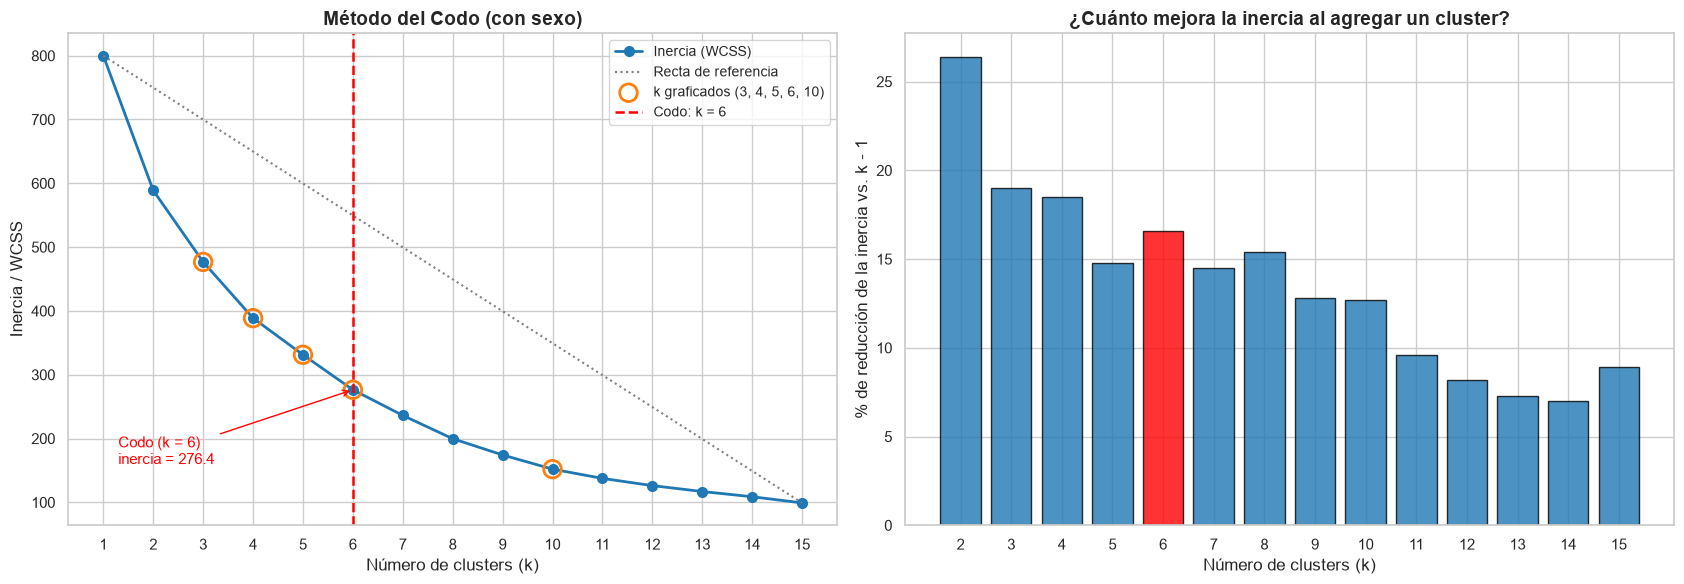

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

# --- Gráfica del codo ---
ax1.plot(rango_k, inercias, marker='o', color='#1f77b4', linewidth=2, markersize=7, label='Inercia (WCSS)')
ax1.plot([rango_k[0], rango_k[-1]], [inercias[0], inercias[-1]], linestyle=':', color='gray', label='Recta de referencia')
k_evaluados = [3, 4, 5, 6, 10]
ax1.scatter(k_evaluados, [inercias[k - 1] for k in k_evaluados], s=160, facecolors='none',
            edgecolors='#ff7f0e', linewidths=2, label='k graficados (3, 4, 5, 6, 10)', zorder=3)
ax1.axvline(k_codo, color='red', linestyle='--', linewidth=1.8, label=f'Codo: k = {k_codo}')
ax1.annotate(f'Codo (k = {k_codo})\ninercia = {inercias[k_codo - 1]:.1f}',
             xy=(k_codo, inercias[k_codo - 1]), xytext=(1.3, 160),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red', ha='left')
ax1.set_xticks(rango_k)
ax1.set_xlabel('Número de clusters (k)', fontsize=12)
ax1.set_ylabel('Inercia / WCSS', fontsize=12)
ax1.set_title('Método del Codo (con sexo)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)

# --- Reducción porcentual de la inercia al agregar un cluster ---
reduccion = tabla_codo['reduccion_vs_k_anterior_%'].iloc[1:]
colores_barras = ['red' if k == k_codo else '#1f77b4' for k in reduccion.index]
ax2.bar(reduccion.index, reduccion.values, color=colores_barras, edgecolor='black', alpha=0.8)
ax2.set_xticks(reduccion.index)
ax2.set_xlabel('Número de clusters (k)', fontsize=12)
ax2.set_ylabel('% de reducción de la inercia vs. k - 1', fontsize=12)
ax2.set_title('¿Cuánto mejora la inercia al agregar un cluster?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Lectura del codo:** la curva es **todavía más suave** que sin sexo. Las reducciones son parecidas entre sí (−26%, −19%, −18%, −15%, −17%) y no hay un quiebre claro. El detector marca **k = 6**, pero las distancias a la recta de k = 5 (0.271), k = 6 (0.276) y k = 7 (0.266) casi empatan.

¿Por qué es tan suave? Porque cada vez que el modelo necesita "bajar inercia" tiene dos opciones con ganancias parecidas: separar un comportamiento nuevo **o** partir un grupo existente por sexo. Eso reparte la mejora entre muchos $k$ y borra el codo.

### Complemento: coeficiente de silueta

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

donde $a(i)$ es la distancia media a su propio cluster y $b(i)$ la distancia media al cluster vecino más cercano (ver `clusters.ipynb` para el detalle).

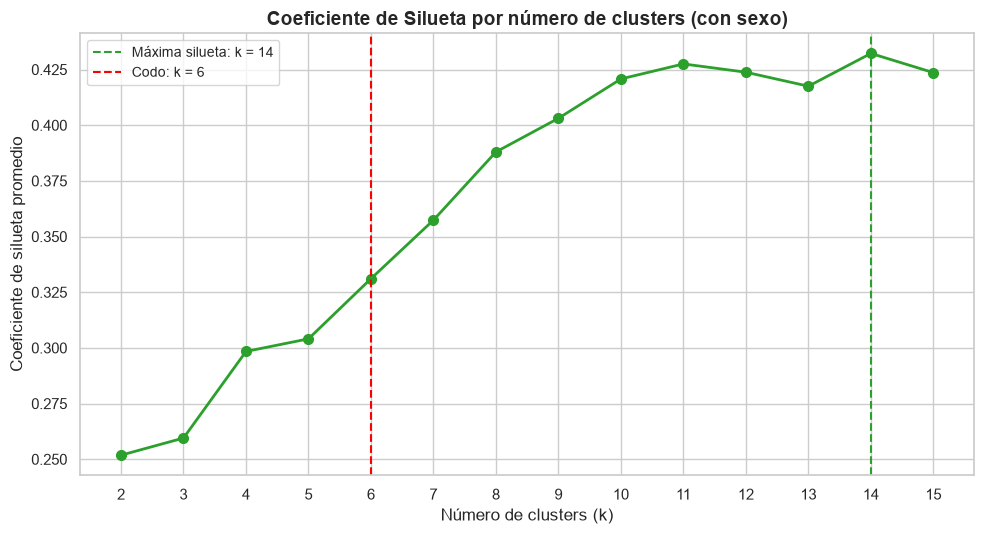

k
2     0.252
3     0.260
4     0.298
5     0.304
6     0.331
7     0.357
8     0.388
9     0.403
10    0.421
11    0.428
12    0.424
13    0.418
14    0.432
15    0.424


In [14]:
rango_k_sil = list(range(2, 16))
siluetas = []
for k in rango_k_sil:
    etiquetas = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA).fit_predict(X_scaled)
    siluetas.append(silhouette_score(X_scaled, etiquetas))

k_mejor_sil = rango_k_sil[int(np.argmax(siluetas))]

plt.figure(figsize=(10, 5.5))
plt.plot(rango_k_sil, siluetas, marker='o', color='#2ca02c', linewidth=2, markersize=7)
plt.axvline(k_mejor_sil, color='#2ca02c', linestyle='--', label=f'Máxima silueta: k = {k_mejor_sil}')
plt.axvline(k_codo, color='red', linestyle='--', label=f'Codo: k = {k_codo}')
plt.xticks(rango_k_sil)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Coeficiente de silueta promedio', fontsize=12)
plt.title('Coeficiente de Silueta por número de clusters (con sexo)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(pd.Series(np.round(siluetas, 3), index=pd.Index(rango_k_sil, name='k'), name='silueta').to_string())

**Lectura de la silueta:** crece casi continuamente hasta $k \approx 10$–$14$ en lugar de tener un máximo claro en un $k$ pequeño. Tiene sentido: el sexo divide los datos en **dos "planos" paralelos** (mujeres en $z = 0.886$, hombres en $z = -1.128$), y la silueta mejora cuando cada plano tiene sus propios clusters. Por eso los mejores valores aparecen con muchos clusters (≈ el doble de los segmentos reales), lo que **no** es una segmentación útil para el negocio.

## 6. Comparación contra el modelo sin sexo

Entrenamos de nuevo el modelo de `clusters.ipynb` (solo edad, ingreso y gasto) y comparamos:

1. **Silueta** con y sin sexo para cada $k$.
2. **Índice de Rand ajustado (ARI):** mide qué tan parecidas son dos particiones de los mismos clientes.
   - $\text{ARI} = 1$: las dos particiones son idénticas (aunque los números de cluster estén cambiados).
   - $\text{ARI} \approx 0$: se parecen lo mismo que dos particiones al azar.

   Se basa en contar **pares de clientes**: ¿los dos modelos coinciden en poner a ese par juntos (o separados)? Y se "ajusta" restando el acuerdo esperado por azar.

*Nota:* comparar siluetas entre espacios de distinta dimensión (3 vs. 4 variables) es orientativo, no una prueba formal, porque las distancias se miden en espacios diferentes.

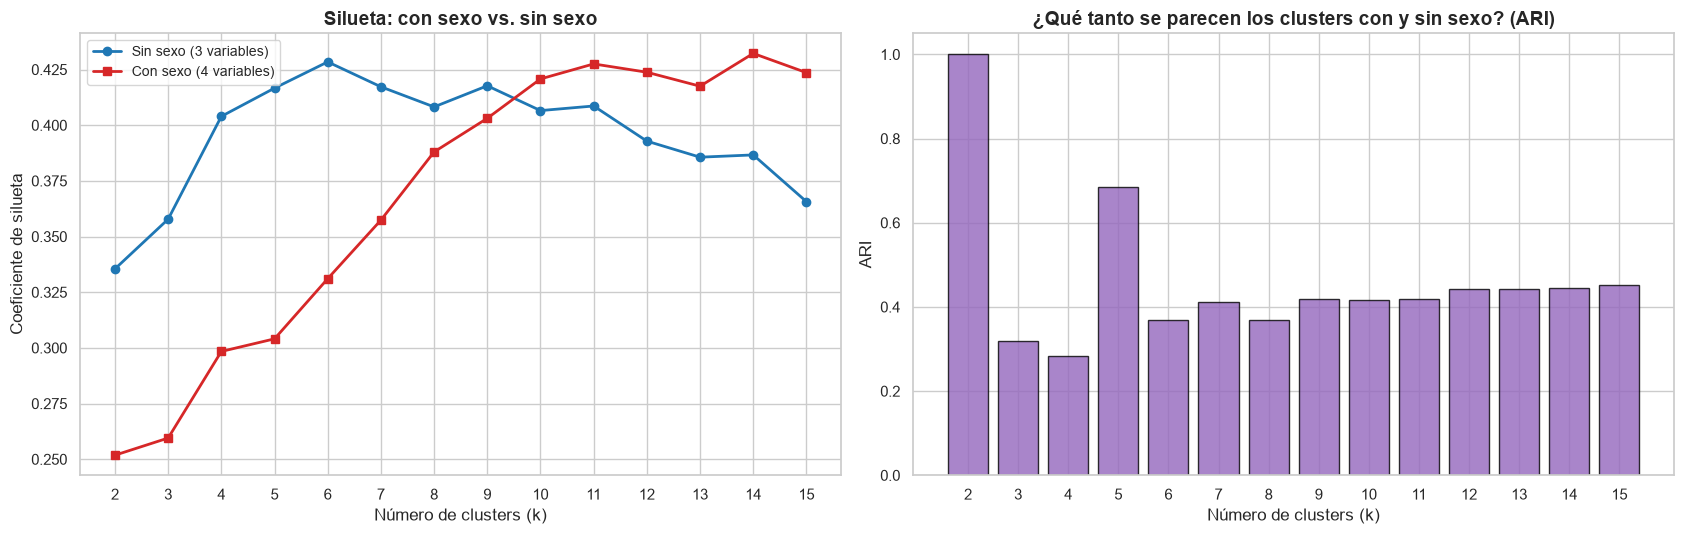

,silueta_sin_sexo,silueta_con_sexo,ARI_con_vs_sin
k,,,
2,0.335,0.252,1.000
3,0.358,0.260,0.320
4,0.404,0.298,0.282
5,0.417,0.304,0.685
6,0.428,0.331,0.369
7,0.417,0.357,0.412
8,0.408,0.388,0.370
9,0.418,0.403,0.420
10,0.407,0.421,0.417


In [15]:
# Modelo de referencia: el mismo de clusters.ipynb (sin sexo), con su propio escalador
FEATURES_SIN_SEXO = ['age', 'annual_income_k', 'spending_score']
X_scaled_sin_sexo = StandardScaler().fit_transform(df[FEATURES_SIN_SEXO])

filas = []
for k in rango_k_sil:
    etiq_sin = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA).fit_predict(X_scaled_sin_sexo)
    etiq_con = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA).fit_predict(X_scaled)
    filas.append({'k': k,
                  'silueta_sin_sexo': silhouette_score(X_scaled_sin_sexo, etiq_sin),
                  'silueta_con_sexo': silhouette_score(X_scaled, etiq_con),
                  'ARI_con_vs_sin': adjusted_rand_score(etiq_sin, etiq_con)})
tabla_comp = pd.DataFrame(filas).set_index('k')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5.5))

ax1.plot(tabla_comp.index, tabla_comp['silueta_sin_sexo'], marker='o', linewidth=2, color='#1f77b4', label='Sin sexo (3 variables)')
ax1.plot(tabla_comp.index, tabla_comp['silueta_con_sexo'], marker='s', linewidth=2, color='#d62728', label='Con sexo (4 variables)')
ax1.set_xticks(rango_k_sil)
ax1.set_xlabel('Número de clusters (k)', fontsize=12)
ax1.set_ylabel('Coeficiente de silueta', fontsize=12)
ax1.set_title('Silueta: con sexo vs. sin sexo', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)

ax2.bar(tabla_comp.index, tabla_comp['ARI_con_vs_sin'], color='#9467bd', edgecolor='black', alpha=0.8)
ax2.set_xticks(rango_k_sil)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('Número de clusters (k)', fontsize=12)
ax2.set_ylabel('ARI', fontsize=12)
ax2.set_title('¿Qué tanto se parecen los clusters con y sin sexo? (ARI)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

tabla_comp.round(3)

**Lectura:**
- **Silueta:** para $k \le 9$ el modelo **sin sexo** tiene clusters mejor definidos (por ejemplo, k = 4: 0.404 sin sexo vs. 0.298 con sexo; k = 5: 0.417 vs. 0.304). Solo con muchos clusters la versión con sexo alcanza valores similares, y es porque duplica los segmentos.
- **ARI:** con k = 2 las particiones son idénticas (ARI = 1: el primer corte en ambos modelos es por edad/gasto, no por sexo). Con k = 5 el parecido es alto (0.685), como vimos en las gráficas. Con k = 3, 4 y 6 el ARI cae a ~0.3–0.4: el sexo cambia por completo la segmentación.

## 7. Conclusiones

| Criterio | Sin sexo (`clusters.ipynb`) | Con sexo (este notebook) |
|---|---|---|
| Codo | k = 4 | k = 6 (muy suave; 5, 6 y 7 casi empatan) |
| Máxima silueta | k = 6 (0.428) | k grande (≈ 10–14), porque duplica segmentos |
| Silueta con k = 5 | 0.417 | 0.304 |
| Clusters de un solo sexo | — | La mayoría para k = 4, 6 y 10 |

1. **Incluir el sexo empeora la segmentación.** Matemáticamente, el corte por sexo elimina toda la inercia de esa variable de un solo golpe, así que K-means lo prefiere aunque hombres y mujeres se comporten igual en ingreso y gasto (EDA, insights 2 y 6).
2. **El sexo no crea segmentos de comportamiento nuevos:** con k = 10 obtenemos aproximadamente los mismos 5 perfiles del modelo sin sexo, uno para mujeres y otro para hombres.
3. **La elección de $k$ se vuelve más difícil:** el codo casi desaparece y la silueta favorece demasiados clusters.

**Recomendación:** mantener el modelo **sin sexo** (`clusters.ipynb`) y usar el sexo solo como variable **descriptiva** de cada cluster. Si el negocio necesitara sí o sí incluirlo, la alternativa correcta sería un algoritmo para datos mixtos (**K-prototypes** o **Gower + clustering jerárquico**) o darle un peso menor a `is_female`, en lugar de meter una variable 0/1 en K-means con el mismo peso que las continuas.